<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Dan\AppData\Local\Temp\ipykernel_7132\1562319350.py:9: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('..\data\processed\df_preprocessed.csv')


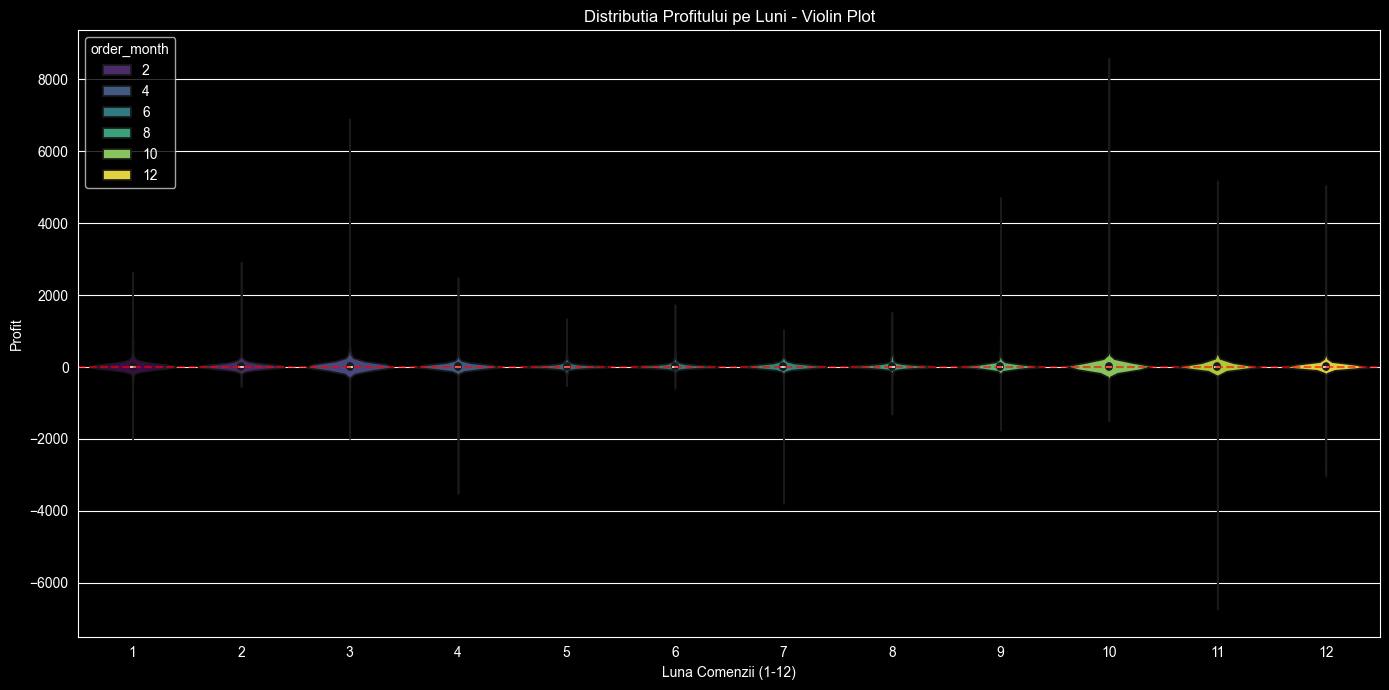

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from matplotlib.ticker import MaxNLocator

df = pd.read_csv('..\data\processed\df_preprocessed.csv')

# 2. Configurarea graficului de tip violin
plt.figure(figsize=(14, 7))
# Analizam distributia profitului pentru fiecare luna (order_month)
sns.violinplot(x='order_month', y='profit', data=df, palette='viridis', hue='order_month')


plt.title('Distributia Profitului pe Luni - Violin Plot')
plt.xlabel('Luna Comenzii (1-12)')
plt.ylabel('Profit')

plt.axhline(0, color='red', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.savefig('correlation_graphs/violin_profit_luni.png')
plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Dan\AppData\Local\Temp\ipykernel_13384\1895250246.py:3: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('..\data\processed\df_preprocessed.csv')


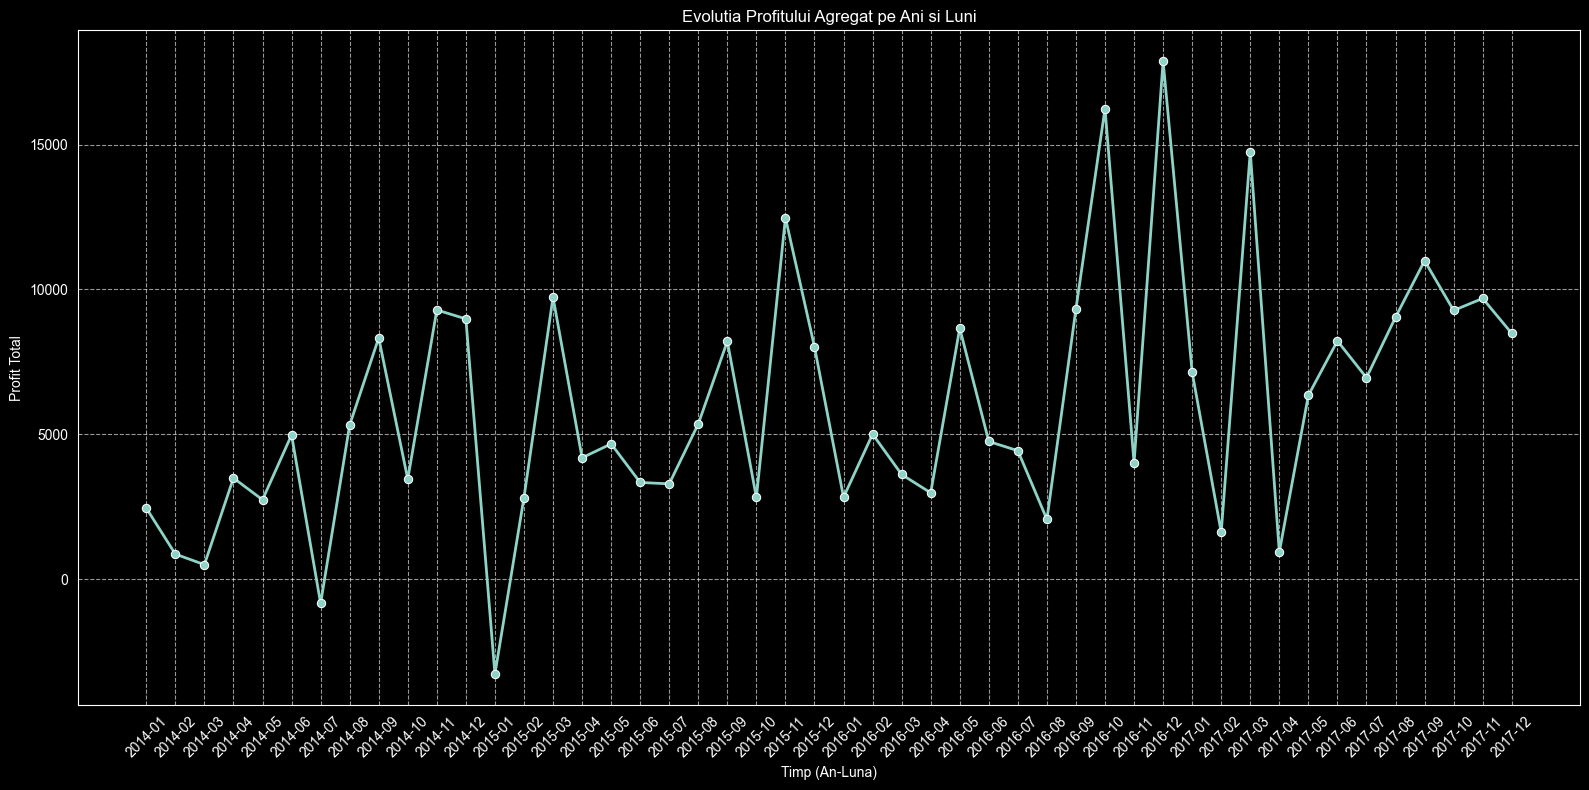

   order_year  order_month     profit  An_Luna
0        2014            1  2450.1907  2014-01
1        2014            2   862.3084  2014-02
2        2014            3   498.7299  2014-03
3        2014            4  3488.8352  2014-04
4        2014            5  2738.7096  2014-05
5        2014            6  4976.5244  2014-06
6        2014            7  -841.4826  2014-07
7        2014            8  5318.1050  2014-08
8        2014            9  8328.0994  2014-09
9        2014           10  3448.2573  2014-10


In [2]:
#profitul lunar pe ani

df = pd.read_csv('..\data\processed\df_preprocessed.csv')

df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

profit_timp = df.groupby(['order_year', 'order_month'])['profit'].sum().reset_index()
profit_timp['An_Luna'] = profit_timp['order_year'].astype(str) + '-' + profit_timp['order_month'].astype(str).str.zfill(2)

plt.figure(figsize=(16, 8))
sns.lineplot(data=profit_timp, x='An_Luna', y='profit', marker='o', linewidth=2)

plt.title('Evolutia Profitului Agregat pe Ani si Luni')
plt.xlabel('Timp (An-Luna)')
plt.ylabel('Profit Total')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(profit_timp.head(10))

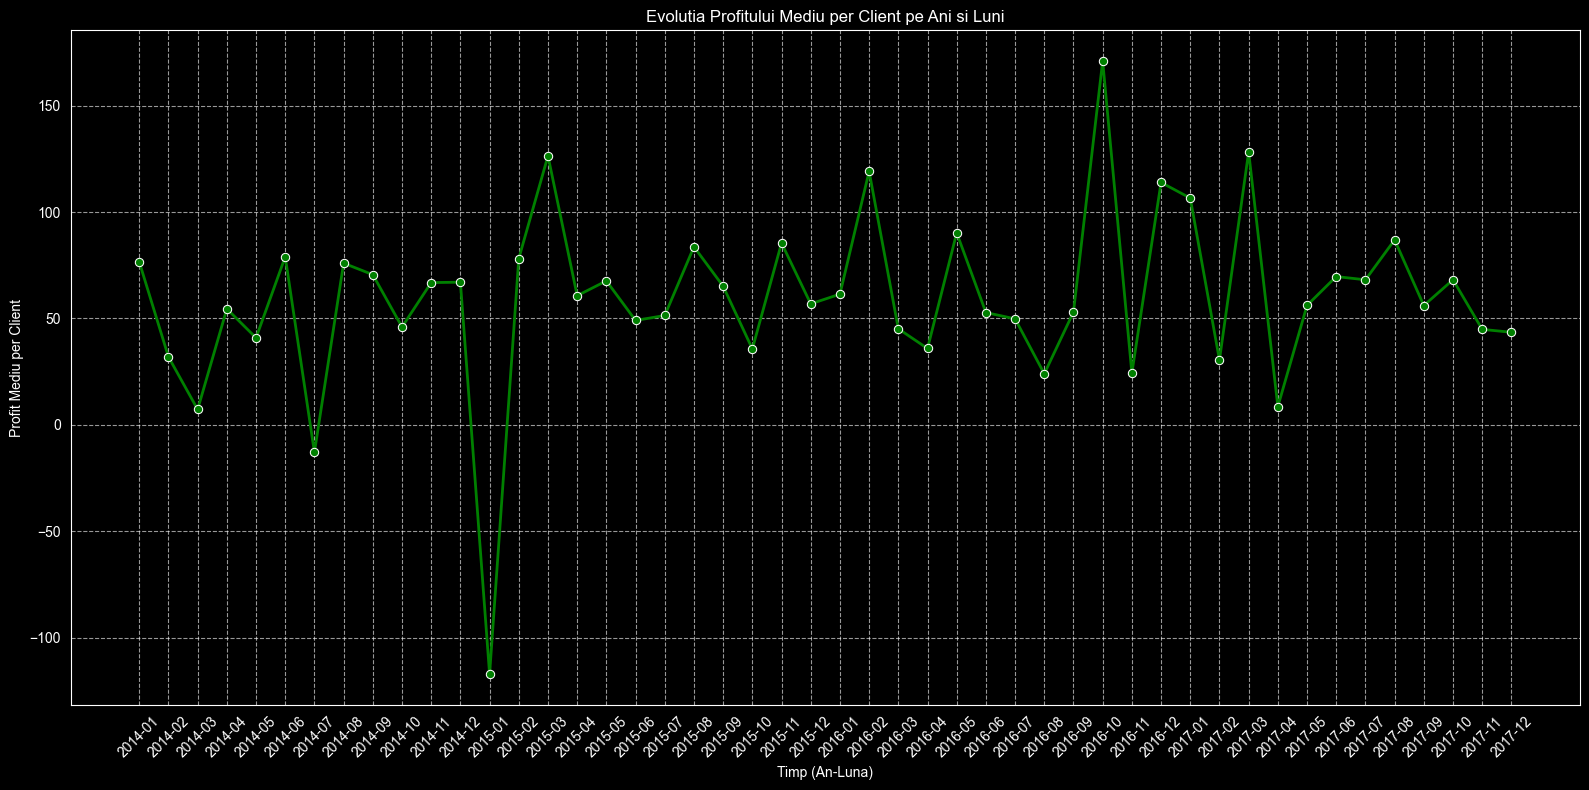

   order_year  order_month     profit  An_Luna
0        2014            1  76.568459  2014-01
1        2014            2  31.937348  2014-02
2        2014            3   7.227970  2014-03
3        2014            4  54.513050  2014-04
4        2014            5  40.876263  2014-05
5        2014            6  78.992451  2014-06
6        2014            7 -12.945886  2014-07
7        2014            8  75.972929  2014-08
8        2014            9  70.577114  2014-09
9        2014           10  45.976764  2014-10


In [3]:
df['order_date'] = pd.to_datetime(df['order_date'])

profit_client_timp = df.groupby(['order_year', 'order_month', 'customer_id'])['profit'].sum().reset_index()

profit_mediu_client = profit_client_timp.groupby(['order_year', 'order_month'])['profit'].mean().reset_index()

profit_mediu_client['An_Luna'] = profit_mediu_client['order_year'].astype(str) + '-' + profit_mediu_client['order_month'].astype(str).str.zfill(2)

plt.figure(figsize=(16, 8))
sns.lineplot(data=profit_mediu_client, x='An_Luna', y='profit', marker='o', color='green', linewidth=2)

plt.title('Evolutia Profitului Mediu per Client pe Ani si Luni')
plt.xlabel('Timp (An-Luna)')
plt.ylabel('Profit Mediu per Client')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(profit_mediu_client.sort_values(by=['order_year', 'order_month']).head(10))

In [4]:
#analiza dec-2014
df_2014 = df[df['order_year'] == 2014].copy()

clienti_pierdere_dec = df_2014[(df_2014['order_month'] == 12) & (df_2014['profit'] < 0)]['customer_id'].unique()

analiza_clienti = df_2014[df_2014['customer_id'].isin(clienti_pierdere_dec)].copy()

analiza_clienti['perioada'] = analiza_clienti['order_month'].apply(lambda x: 'Decembrie' if x == 12 else 'Restul Anului')

rezultat_comparativ = analiza_clienti.groupby(['customer_id', 'perioada']).agg({
    'profit': 'sum',
    'sales': 'sum',
    'discount': 'mean'
}).unstack(fill_value=0)

print("Comparatie Profit: Decembrie vs Restul Anului pentru clientii cu pierderi:")
print(rezultat_comparativ['profit'].head(10))

print("\nIdentificarea produselor specifice care au generat pierderi pentru acesti clienti in Decembrie:")
produse_pierdere = df_2014[
    (df_2014['customer_id'].isin(clienti_pierdere_dec)) &
    (df_2014['order_month'] == 12) &
    (df_2014['profit'] < 0)
].groupby(['customer_id', 'product_name']).agg({
    'profit': 'sum',
    'discount': 'max'
}).sort_values(by='profit')

print(produse_pierdere.head(10))

Comparatie Profit: Decembrie vs Restul Anului pentru clientii cu pierderi:
perioada     Decembrie  Restul Anului
customer_id                          
AD-10180       -8.5794         1.9845
AR-10345     -242.4396         0.0000
BK-11260     -180.1676        51.1464
CA-12265      -14.7730        31.4620
CC-12670       11.2614         0.0000
CS-11845      -13.8960         0.0000
CT-11995       69.8868       215.8138
CY-12745     -336.6272         0.0000
Co-12640      -16.7696       159.1806
DD-13570       -8.8038         0.1694

Identificarea produselor specifice care au generat pierderi pentru acesti clienti in Decembrie:
                                                                  profit  \
customer_id product_name                                                   
RP-19390    GBC DocuBind 300 Electric Binding Machine          -694.2936   
MF-17665    Ibico Ibimaster 300 Manual Binding System          -459.9875   
CY-12745    GBC DocuBind 300 Electric Binding Machine          -336.

In [5]:
df_dec_2014 = df[(df['order_year'] == 2014) & (df['order_month'] == 12)].copy()
vanzari_pierdere = df_dec_2014[df_dec_2014['profit'] < 0]['sales'].sum()

vanzari_totale_dec = df_dec_2014['sales'].sum()

procent_vanzari_pierdere = (vanzari_pierdere / vanzari_totale_dec) * 100

print(f"Vanzari produse cu pierderi: {vanzari_pierdere:.2f}")
print(f"Vanzari totale Decembrie 2014: {vanzari_totale_dec:.2f}")
print(f"Ponderea vanzarilor generatoare de pierderi: {procent_vanzari_pierdere:.2f}%")

Vanzari produse cu pierderi: 10933.52
Vanzari totale Decembrie 2014: 69545.62
Ponderea vanzarilor generatoare de pierderi: 15.72%


In [6]:
#analzia pierdere ian-2015
df_jan_2015 = df[(df['order_year'] == 2015) & (df['order_month'] == 1)].copy()

profit_total_jan = df_jan_2015['profit'].sum()
print(f"Profit total Ianuarie 2015: {profit_total_jan:.2f}")

pierderi_jan = df_jan_2015[df_jan_2015['profit'] < 0].copy()
pierderi_total_jan = pierderi_jan['profit'].sum()
top_pierderi = pierderi_jan.sort_values(by='profit').head(5)

pierderi_cat = pierderi_jan.groupby('category')['profit'].sum().sort_values()
pierderi_subcat = pierderi_jan.groupby('sub-category')['profit'].sum().sort_values()

vanzari_pierdere = pierderi_jan['sales'].sum()
vanzari_totale = df_jan_2015['sales'].sum()
pondere = (vanzari_pierdere / vanzari_totale) * 100

print("\nTop 5 tranzactii cu pierderi:")
print(top_pierderi[['customer_id', 'sub-category', 'product_name', 'sales', 'discount', 'profit']])

print("\nPierderi pe Categorii:")
print(pierderi_cat)

print("\nPierderi pe Sub-Categorii (Top):")
print(pierderi_subcat.head(5))

print(f"\nVanzari totale Jan 2015: {vanzari_totale:.2f}")
print(f"Profit total Jan 2015: {profit_total_jan:.2f}")
print(f"Pierdere totala Jan 2015: {pierderi_total_jan:.2f}")
print(f"\nPonderea vanzarilor pe minus: {pondere:.2f}%")

Profit total Ianuarie 2015: -3281.01

Top 5 tranzactii cu pierderi:
     customer_id sub-category  \
9639    JH-15985       Tables   
215     VW-21775     Machines   
5055    AH-10465    Bookcases   
1669    MM-17920       Tables   
467     JS-15940  Furnishings   

                                           product_name      sales  discount  \
9639  Chromcraft Bull-Nose Wood Oval Conference Tabl...  4297.6440      0.40   
215                  Cisco 9971 IP Video Phone Charcoal  1188.0000      0.70   
5055     O'Sullivan Living Dimensions 5-Shelf Bookcases  1352.3976      0.32   
1669  Bush Advantage Collection Racetrack Conference...  1018.1040      0.40   
467   Eldon ClusterMat Chair Mat with Cordless Antis...   254.7440      0.60   

         profit  
9639 -1862.3124  
215   -950.4000  
5055  -437.5404  
1669  -373.3048  
467   -312.0614  

Pierderi pe Categorii:
category
Furniture         -3312.7782
Technology        -1166.6846
Office Supplies      -1.3566
Name: profit, dtype: flo

Pierdere din Ianuarie 2015 este conjucturala si se datoreaza dicounturlor mari din category: "Furniture", sub-category: "Tables", un singur produs din aceasta categorie, "Chromcraft Bull-Nose Wood Oval Conference Tabl" a generat peste 50% din pierderea lunii.

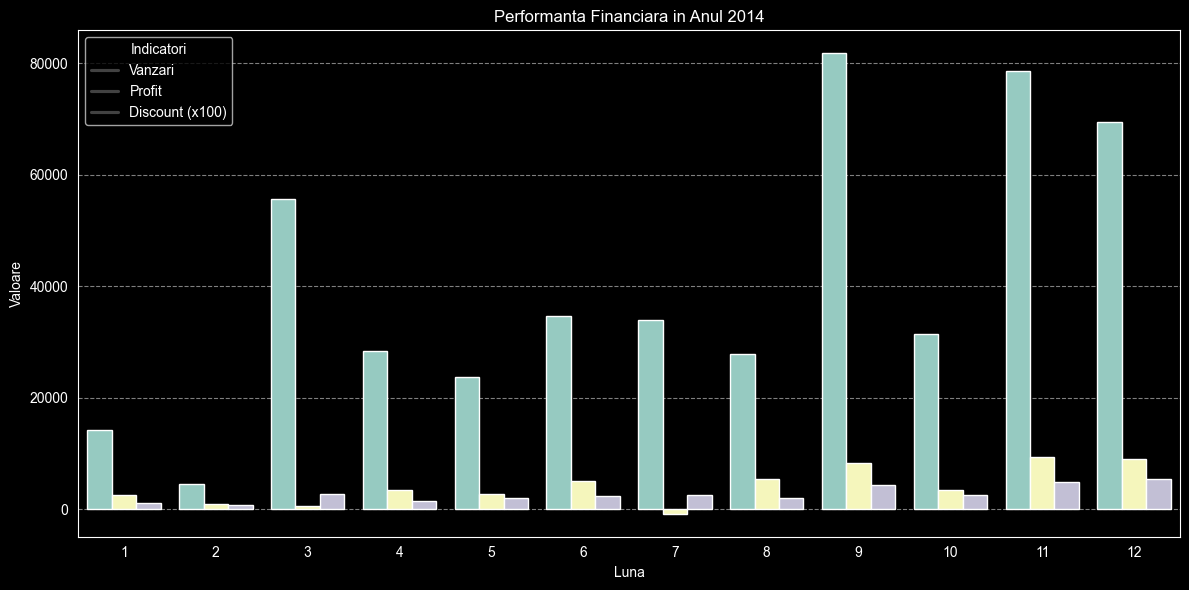

Statistici pentru anul 2014:
 order_month      sales    profit  discount
           1 14236.8950 2450.1907     10.00
           2  4519.8920  862.3084      8.10
           3 55691.0090  498.7299     26.30
           4 28295.3450 3488.8352     14.85
           5 23648.2870 2738.7096     18.95
           6 34595.1276 4976.5244     23.22
           7 33946.3930 -841.4826     24.55
           8 27909.4685 5318.1050     20.05
           9 81777.3508 8328.0994     42.87
          10 31453.3930 3448.2573     25.45
          11 78628.7167 9292.1269     48.07
          12 69545.6205 8983.5699     53.05
--------------------------------------------------


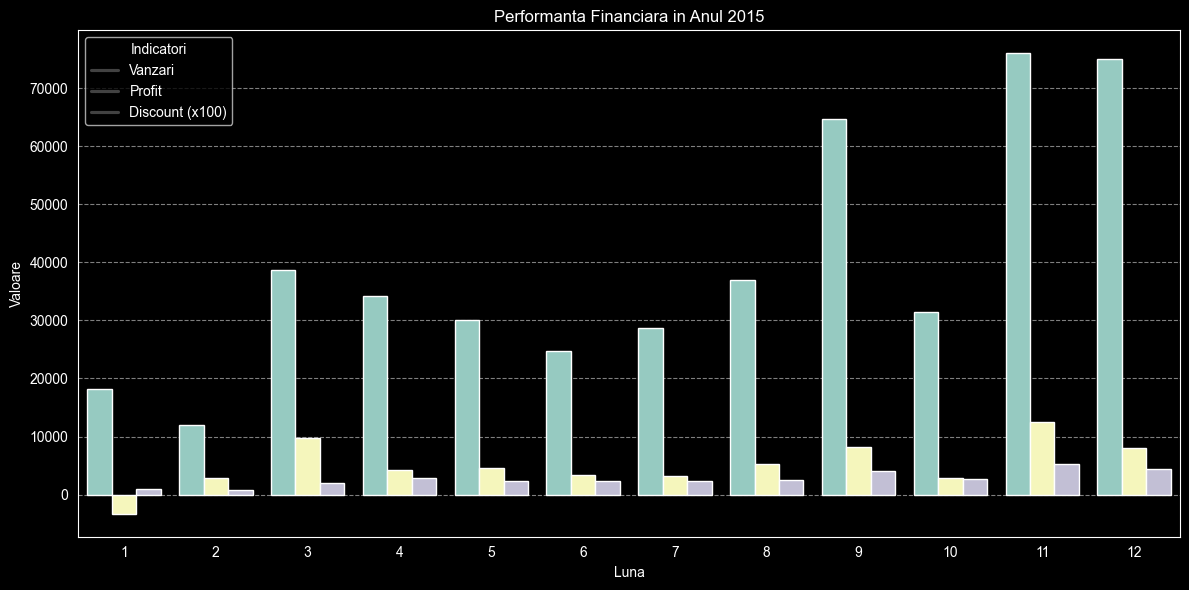

Statistici pentru anul 2015:
 order_month      sales     profit  discount
           1 18174.0756 -3281.0070     10.32
           2 11951.4110  2813.8508      8.30
           3 38726.2520  9732.0978     19.34
           4 34195.2085  4187.4962     28.15
           5 30131.6865  4667.8690     24.25
           6 24797.2920  3335.5572     23.80
           7 28765.3250  3288.6483     23.85
           8 36898.3322  5355.8084     24.87
           9 64595.9180  8209.1627     41.30
          10 31404.9235  2817.3660     26.95
          11 75972.5635 12474.7884     52.59
          12 74919.5212  8016.9659     43.37
--------------------------------------------------


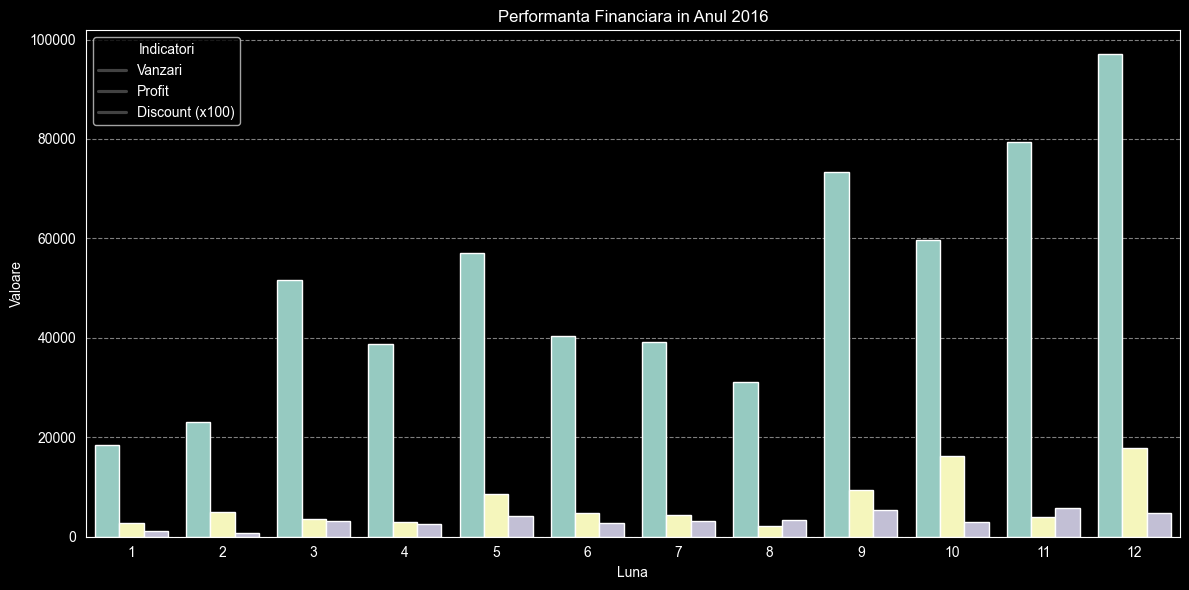

Statistici pentru anul 2016:
 order_month      sales     profit  discount
           1 18542.4910  2824.8233     11.80
           2 22978.8150  5004.5795      8.00
           3 51715.8750  3611.9680     31.12
           4 38750.0390  2977.8149     26.50
           5 56987.7280  8662.1464     41.50
           6 40344.5340  4750.3781     27.60
           7 39261.9630  4432.8779     32.05
           8 31115.3743  2062.0693     32.67
           9 73410.0249  9328.6576     54.24
          10 59687.7450 16243.1425     28.85
          11 79411.9658  4011.4075     58.32
          12 96999.0430 17885.3093     47.67
--------------------------------------------------


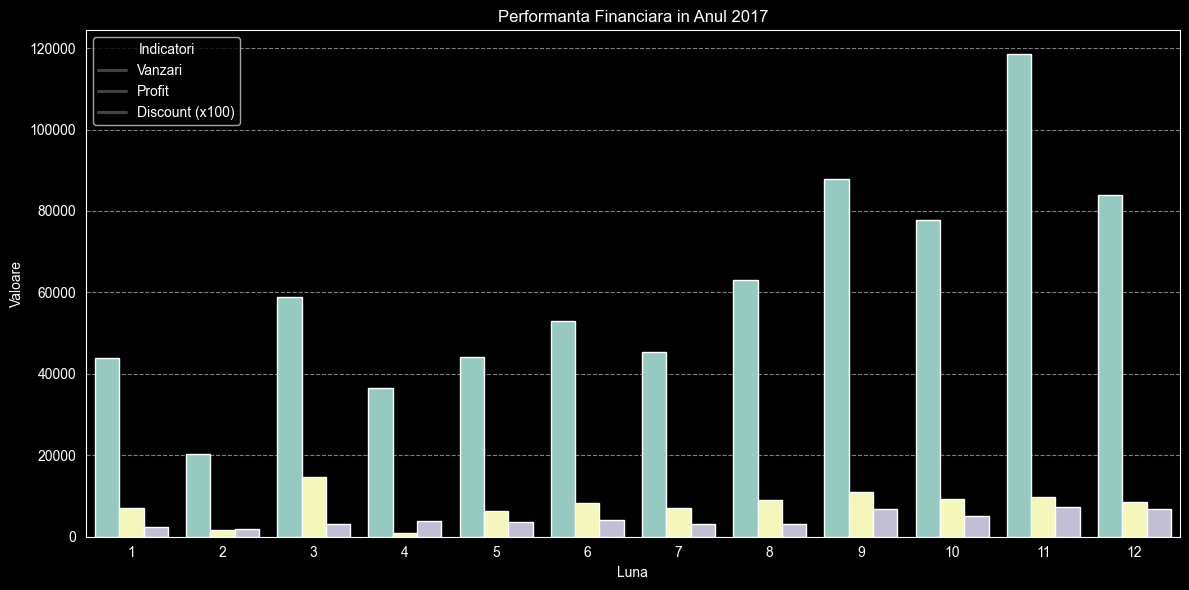

Statistici pentru anul 2017:
 order_month       sales     profit  discount
           1  43971.3740  7140.4391     25.00
           2  20301.1334  1613.8720     19.47
           3  58872.3528 14751.8915     31.14
           4  36521.5361   933.2900     39.47
           5  44261.1102  6342.5828     36.89
           6  52981.7257  8223.3357     42.12
           7  45264.4160  6952.6212     31.65
           8  63120.8880  9040.9557     31.30
           9  87866.6520 10991.5556     67.65
          10  77776.9232  9275.2755     51.92
          11 118447.8250  9690.1037     73.89
          12  83829.3188  8483.3468     67.72
--------------------------------------------------


In [7]:
ani_unici = sorted(df['order_year'].unique())

for an in ani_unici:
    df_an = df[df['order_year'] == an]

    stats_luna = df_an.groupby('order_month').agg({
        'sales': 'sum',
        'profit': 'sum',
        'discount': 'sum'
    }).reset_index()

    stats_luna['discount_scaled'] = stats_luna['discount'] * 100

    stats_melted = stats_luna.melt(id_vars='order_month',
                                   value_vars=['sales', 'profit', 'discount_scaled'],
                                   var_name='Metrica',
                                   value_name='Valoare')

    plt.figure(figsize=(12, 6))
    sns.barplot(data=stats_melted, x='order_month', y='Valoare', hue='Metrica')

    plt.title(f'Performanta Financiara in Anul {an}')
    plt.xlabel('Luna')
    plt.ylabel('Valoare')
    plt.legend(title='Indicatori', labels=['Vanzari', 'Profit', 'Discount (x100)'])
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"Statistici pentru anul {an}:")
    print(stats_luna[['order_month', 'sales', 'profit', 'discount']].to_string(index=False))
    print("-" * 50)

Lunile cu sezonalitate ridicata dpdv Profit &Vanzari sunt Martie, Septembrie-Decembrie.

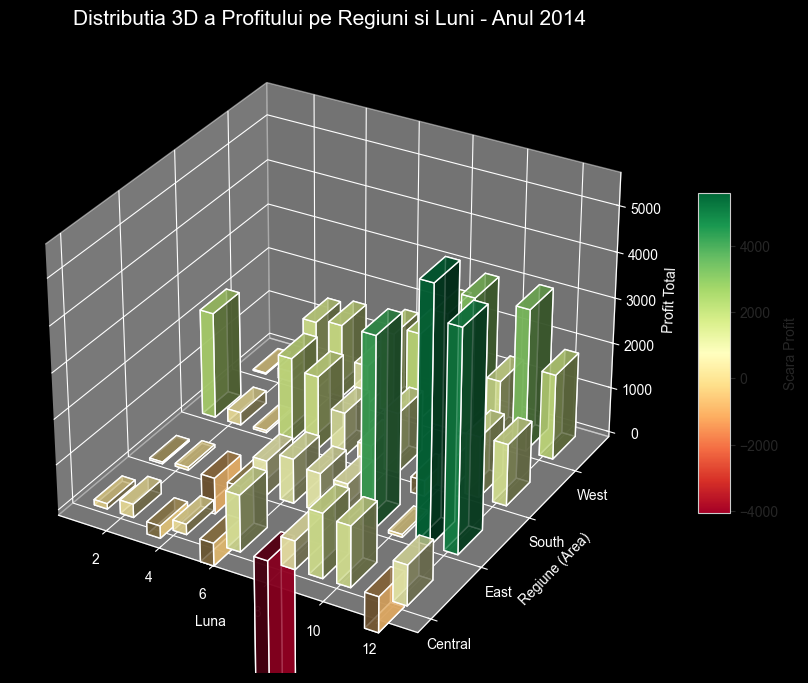

Grafic 3D generat pentru anul 2014.
--------------------------------------------------


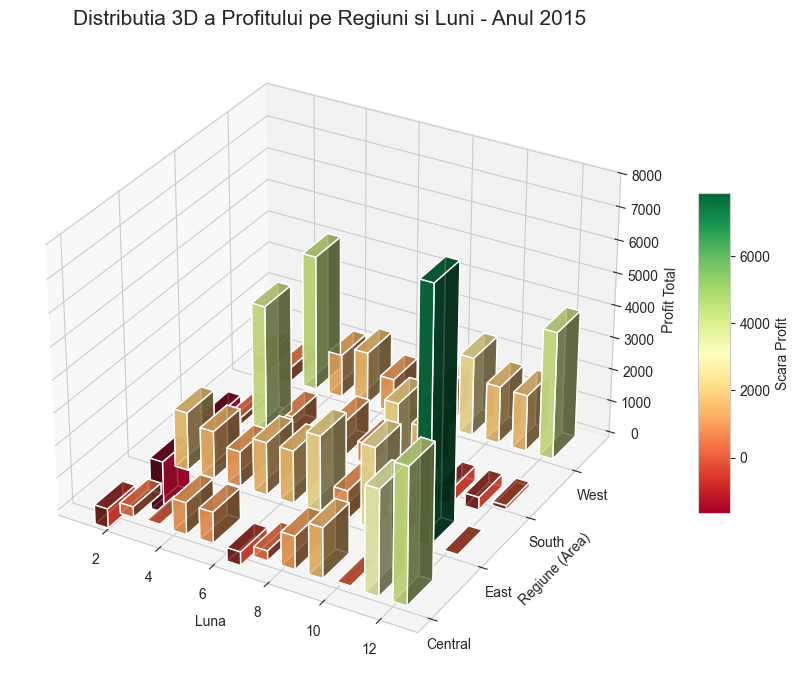

Grafic 3D generat pentru anul 2015.
--------------------------------------------------


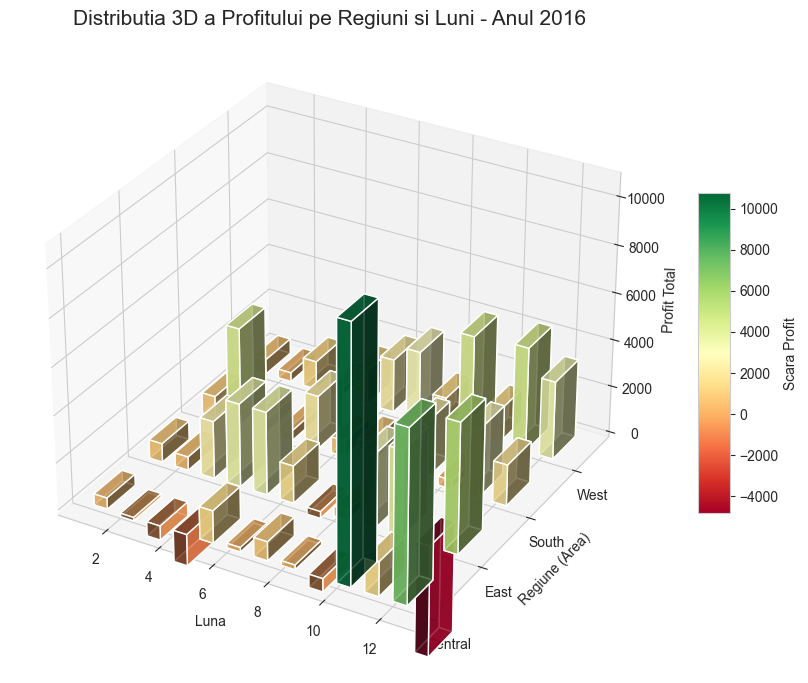

Grafic 3D generat pentru anul 2016.
--------------------------------------------------


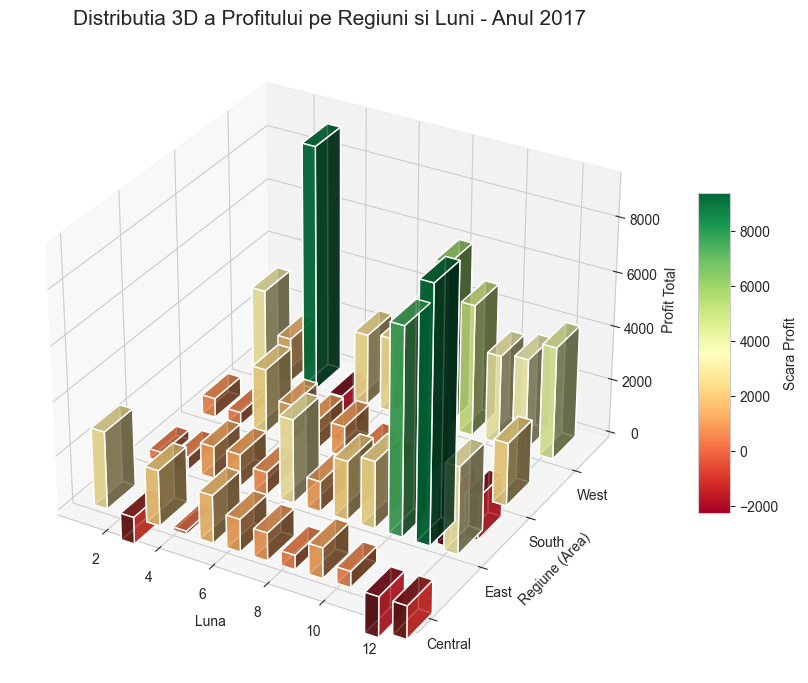

Grafic 3D generat pentru anul 2017.
--------------------------------------------------


In [8]:
le = LabelEncoder()
df['region_encoded'] = le.fit_transform(df['region'])
regiuni = le.classes_

ani_unici = sorted(df['order_year'].unique())

for an in ani_unici:
    df_an = df[df['order_year'] == an]

    stats = df_an.groupby(['order_month', 'region_encoded']).agg({
        'profit': 'sum'
    }).reset_index()

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Setam estetica folosind seaborn
    sns.set_style("whitegrid")

    x = stats['order_month']
    y = stats['region_encoded']
    z = np.zeros(len(stats))

    dx = dy = 0.5
    dz = stats['profit']

    # Culori bazate pe valoarea profitului (paleta seaborn)
    norm = plt.Normalize(dz.min(), dz.max())
    colors = plt.cm.RdYlGn(norm(dz))

    ax.bar3d(x, y, z, dx, dy, dz, color=colors, alpha=0.8)

    ax.set_title(f'Distributia 3D a Profitului pe Regiuni si Luni - Anul {an}', fontsize=15)
    ax.set_xlabel('Luna')
    ax.set_ylabel('Regiune (Area)')
    ax.set_zlabel('Profit Total')

    ax.set_yticks(range(len(regiuni)))
    ax.set_yticklabels(regiuni)

    # Adaugam o bara de culori pentru referinta
    mappable = plt.cm.ScalarMappable(norm=norm, cmap='RdYlGn')
    fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=10, label='Scara Profit')

    plt.subplots_adjust(top=0.9, bottom=0.1, left=0.1, right=0.9, hspace=0.4, wspace=0.4)
    plt.show()

    print(f"Grafic 3D generat pentru anul {an}.")
    print("-" * 50)

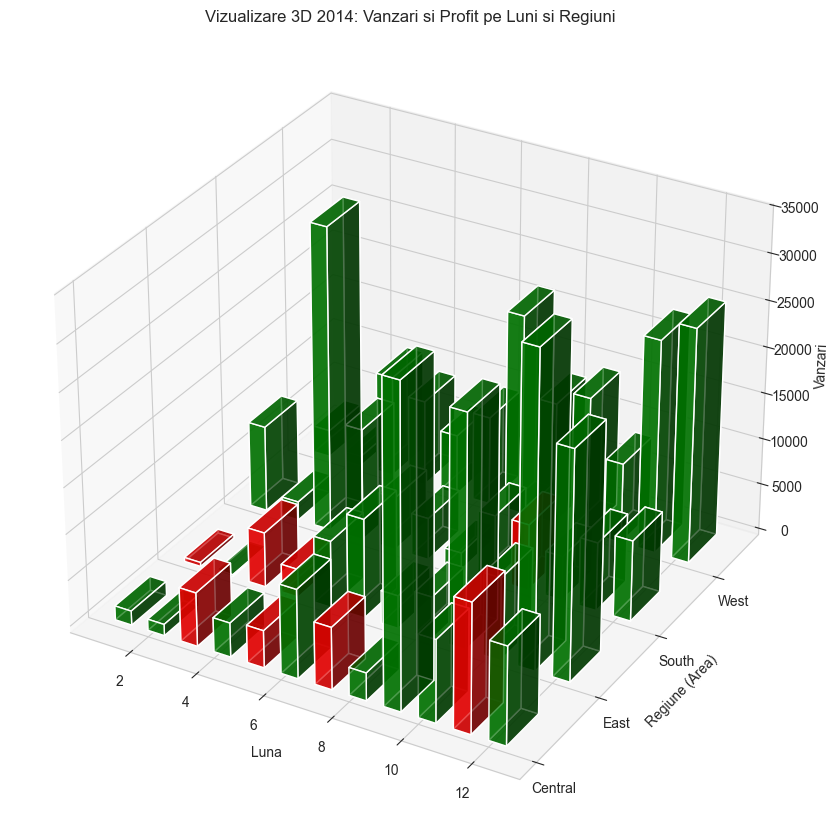

Grafic generat pentru anul 2014 pe regiuni.
------------------------------------------------------------


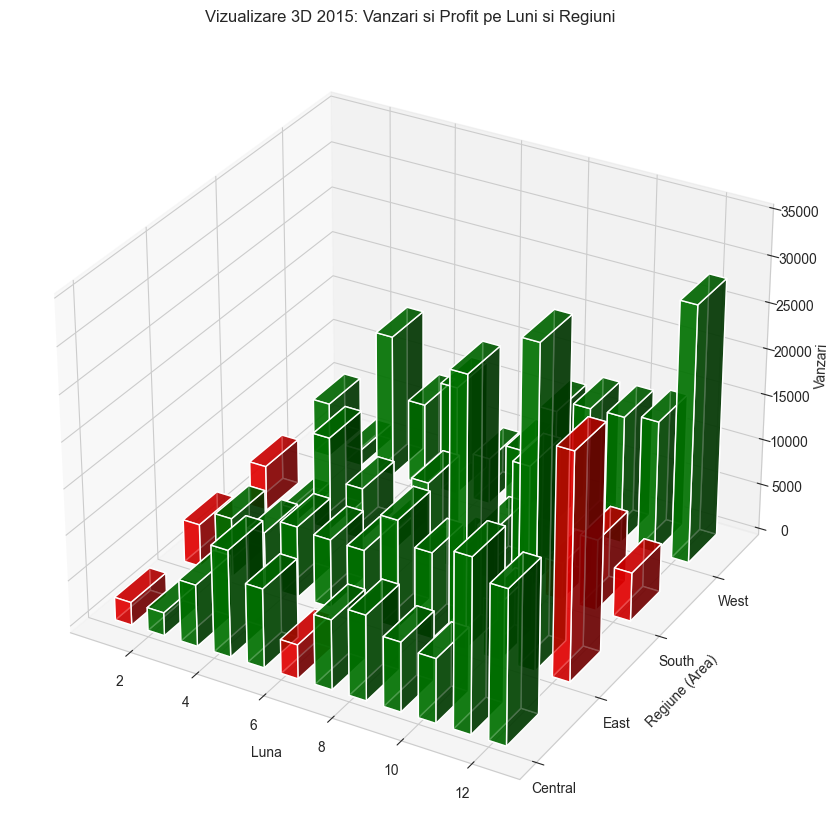

Grafic generat pentru anul 2015 pe regiuni.
------------------------------------------------------------


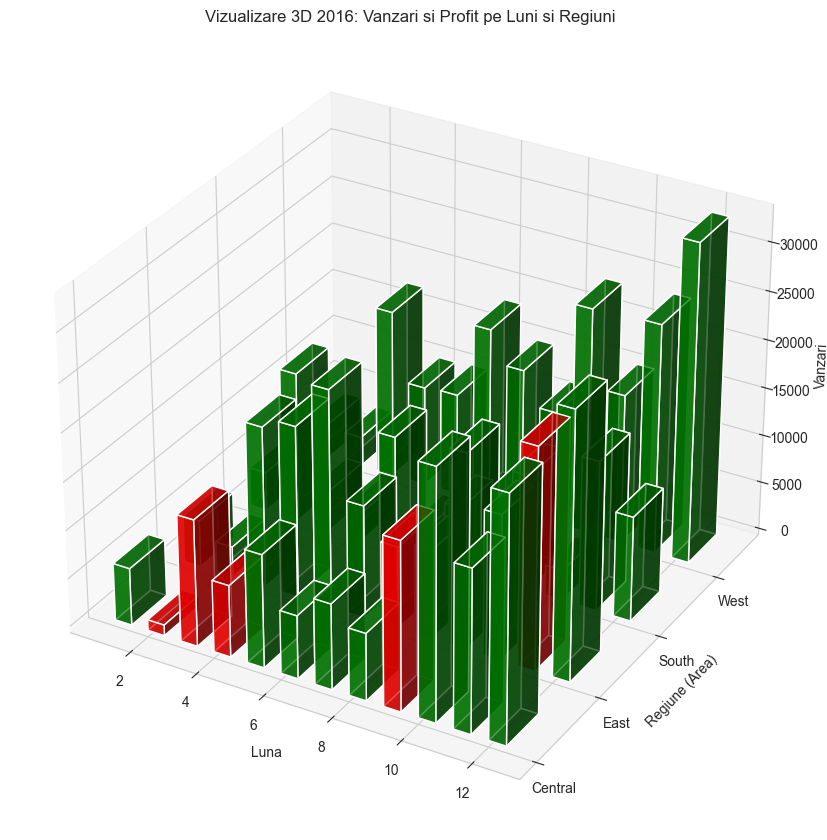

Grafic generat pentru anul 2016 pe regiuni.
------------------------------------------------------------


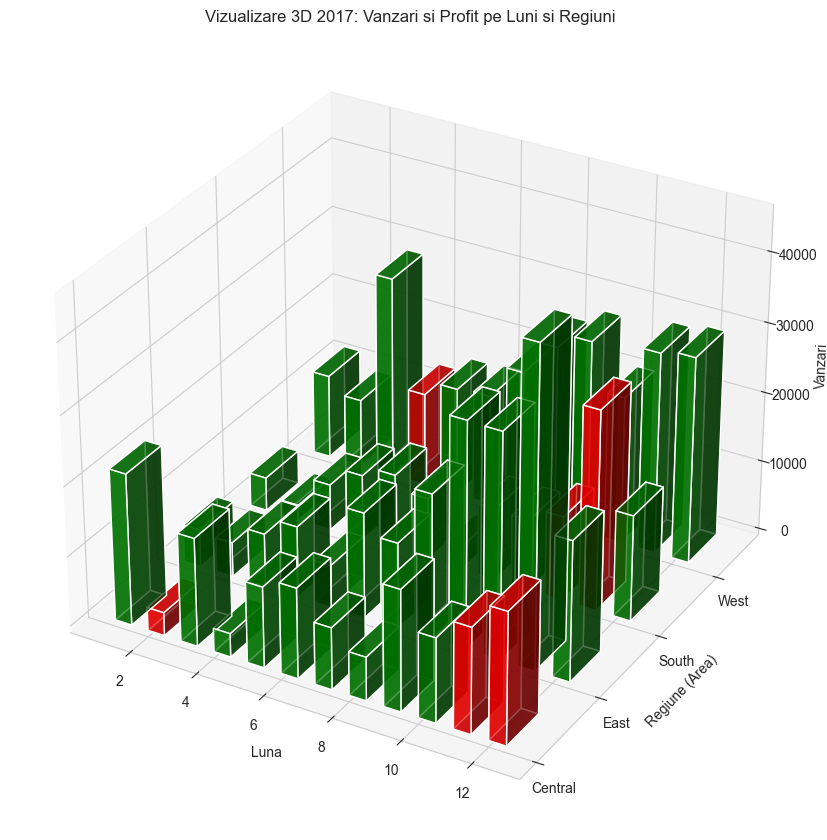

Grafic generat pentru anul 2017 pe regiuni.
------------------------------------------------------------


In [9]:
ani_unici = sorted(df['order_year'].unique())
regiuni_unice = sorted(df['region'].unique())
regiune_to_id = {regiune: i for i, regiune in enumerate(regiuni_unice)}

for an in ani_unici:
    df_an = df[df['order_year'] == an]

    stats_3d = df_an.groupby(['order_month', 'region']).agg({
        'sales': 'sum',
        'profit': 'sum'
    }).reset_index()

    stats_3d['region_id'] = stats_3d['region'].map(regiune_to_id)

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    x = stats_3d['order_month']
    y = stats_3d['region_id']
    z = np.zeros(len(stats_3d))

    dx = 0.5
    dy = 0.5
    dz = stats_3d['sales']

    colors = ['green' if p > 0 else 'red' for p in stats_3d['profit']]

    ax.bar3d(x, y, z, dx, dy, dz, color=colors, alpha=0.7)

    ax.set_xlabel('Luna')
    ax.set_ylabel('Regiune (Area)')
    ax.set_zlabel('Vanzari')

    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_yticks(range(len(regiuni_unice)))
    ax.set_yticklabels(regiuni_unice)

    plt.title(f'Vizualizare 3D {an}: Vanzari si Profit pe Luni si Regiuni')

    plt.subplots_adjust(top=0.9, bottom=0.1, left=0.1, right=0.9, hspace=0.4, wspace=0.4)
    plt.show()

    print(f"Grafic generat pentru anul {an} pe regiuni.")
    print("-" * 60)

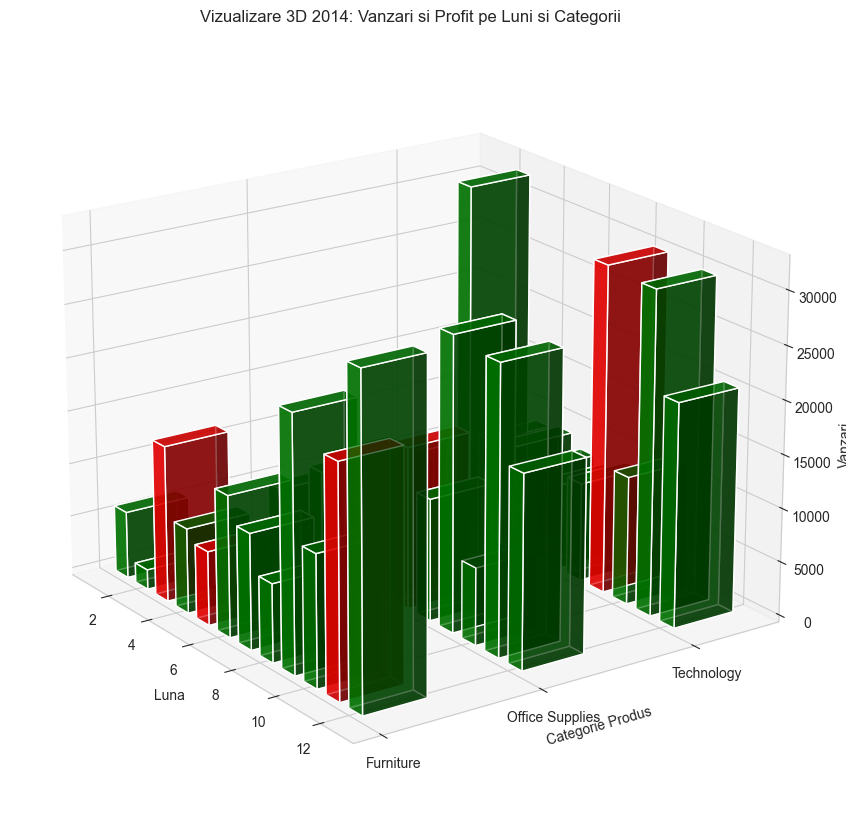

Grafic 3D pentru anul 2014 pe categorii finalizat.
------------------------------------------------------------


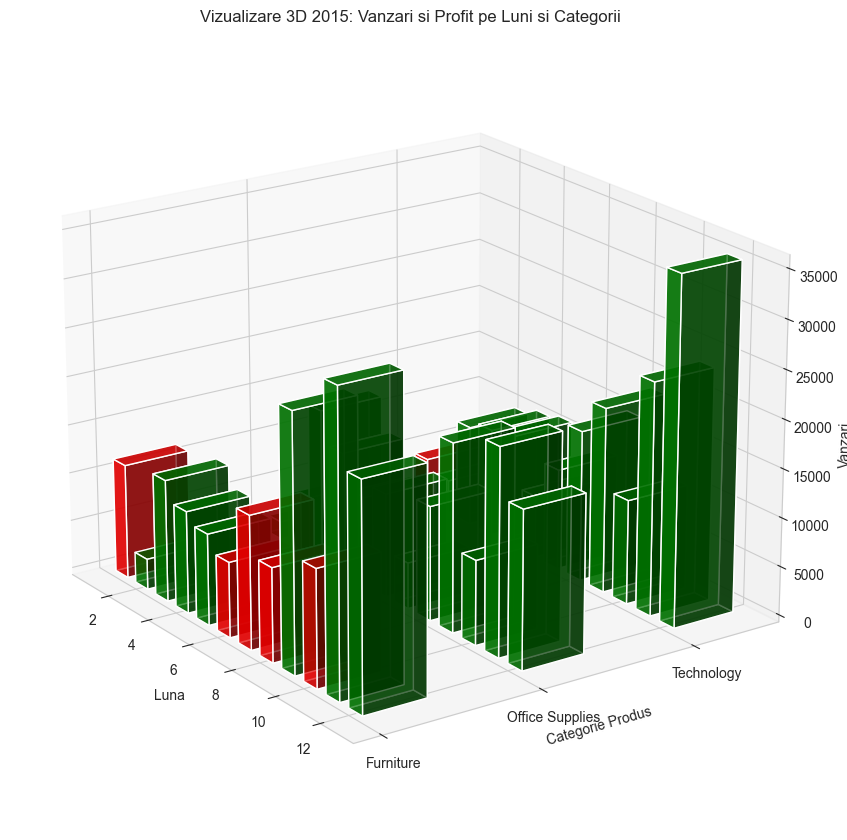

Grafic 3D pentru anul 2015 pe categorii finalizat.
------------------------------------------------------------


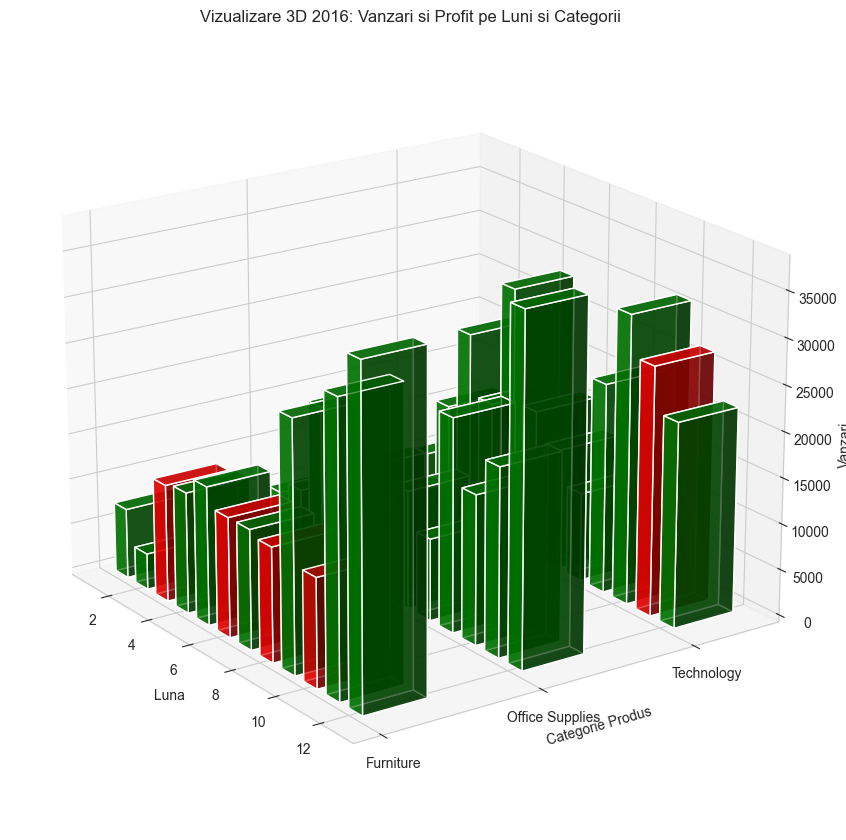

Grafic 3D pentru anul 2016 pe categorii finalizat.
------------------------------------------------------------


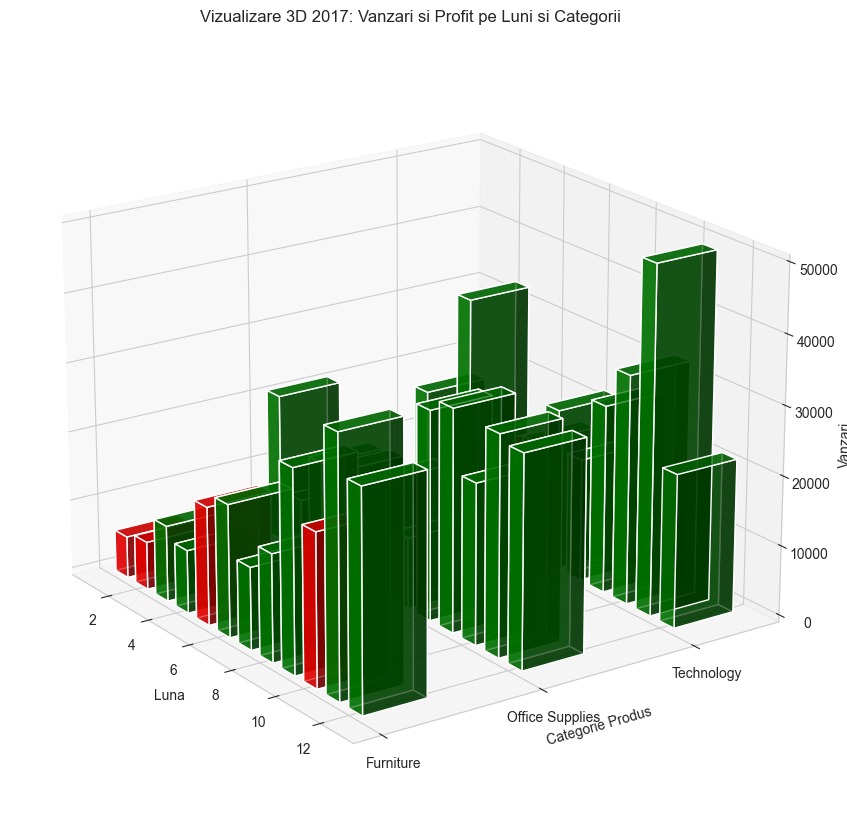

Grafic 3D pentru anul 2017 pe categorii finalizat.
------------------------------------------------------------


In [10]:
ani_unici = sorted(df['order_year'].unique())
categorii_unice = sorted(df['category'].unique())
categorie_to_id = {cat: i for i, cat in enumerate(categorii_unice)} # eliminare f-string

for an in ani_unici:
    df_an = df[df['order_year'] == an]

    stats_3d = df_an.groupby(['order_month', 'category']).agg({
        'sales': 'sum',
        'profit': 'sum'
    }).reset_index()

    stats_3d['category_id'] = stats_3d['category'].map(categorie_to_id)

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    x = stats_3d['order_month'].values
    y = stats_3d['category_id'].values
    z = np.zeros(len(stats_3d))

    dx = 0.6
    dy = 0.4
    dz = stats_3d['sales'].values

    colors = ['green' if p > 0 else 'red' for p in stats_3d['profit']]

    ax.bar3d(x, y, z, dx, dy, dz, color=colors, alpha=0.7)

    ax.set_xlabel('Luna')
    ax.set_ylabel('Categorie Produs')
    ax.set_zlabel('Vanzari')

    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_yticks(range(len(categorii_unice)))
    ax.set_yticklabels(categorii_unice)

    titlu = "Vizualizare 3D " + str(an) + ": Vanzari si Profit pe Luni si Categorii"
    plt.title(titlu)

    ax.view_init(elev=20, azim=-35)

    plt.subplots_adjust(top=0.9, bottom=0.1, left=0.1, right=0.9, hspace=0.4, wspace=0.4)
    plt.show()

    print("Grafic 3D pentru anul " + str(an) + " pe categorii finalizat.")
    print("-" * 60)